In [1]:
# ==============================================================================
# CELL 1: Environment Setup & Imports
# ==============================================================================
import os
import sys
import gc
import json
import time
import random
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.amp import autocast, GradScaler
from torchvision import transforms

import timm
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())

PyTorch Version : 2.10.0+cu128
CUDA Available  : True


In [2]:
# ==============================================================================
# CELL 2: Global Configuration
# ==============================================================================
DEBUG_MODE = False  # Set to True to test end-to-end functionality in ~1 minute

CONFIG = {
    "seed": 42,
    "model_name": "vit_tiny_patch16_224",
    "image_size": 224,
    "batch_size": 16,
    "num_workers": 2,
    "grad_accum_steps": 1,
    "mixed_precision": torch.cuda.is_available(),
    
    # Dataset Limits
    "total_samples":  20000,
    "train_samples":  16000,
    "val_samples": 2000,
    "test_samples": 2000,
    
    # Contrastive Stage
    "contrastive_epochs": 50,
    "contrastive_lr": 1e-4,
    "temperature": 0.5,
    "hidden_dim": 512,
    "projection_dim": 128,
    
    # Fine-Tuning Stage
    "finetune_epochs": 50,
    "finetune_lr": 1e-4,
    "weight_decay": 1e-4,
    "freeze_encoder": False,  # Full fine-tuning by default
    "num_classes": 2,
    
    "output_dir": "/kaggle/working/pipeline2_contrastive_vit"
}

# Create required output directory structures
base_dir = Path(CONFIG["output_dir"])
checkpoints_dir = base_dir / "checkpoints"
indices_dir = base_dir / "indices"
results_dir = base_dir / "results"
config_dir = base_dir / "config"

for d in [checkpoints_dir, indices_dir, results_dir, config_dir]:
    d.mkdir(parents=True, exist_ok=True)

with open(config_dir / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=4)

print("Configuration initialized successfully.")

Configuration initialized successfully.


In [3]:
# ==============================================================================
# CELL 3: Reproducibility Settings
# ==============================================================================
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])
print(f"Global seed fixed to: {CONFIG['seed']}")

Global seed fixed to: 42


In [4]:
# ==============================================================================
# CELL 4: GPU & RAM Resource Inspection
# ==============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Target Device:", device)

if torch.cuda.is_available():
    print("GPU Model  :", torch.cuda.get_device_name(0))
    print("VRAM Free  :", f"{torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")
    print("VRAM Total :", f"{torch.cuda.mem_get_info()[1] / 1e9:.2f} GB")

import psutil
ram = psutil.virtual_memory()
print(f"System RAM Free: {ram.available / 1e9:.2f} GB / {ram.total / 1e9:.2f} GB")

Target Device: cuda
GPU Model  : Tesla T4
VRAM Free  : 15.53 GB
VRAM Total : 15.64 GB
System RAM Free: 31.67 GB / 33.66 GB


In [5]:
# ==============================================================================
# SECTION 5 — PCam HDF5 Path Resolution
# ==============================================================================
# Using the training split files from your dataset input
X_H5_PATH = "/kaggle/input/datasets/tarequlislam8/pcam-dataset/camelyonpatch_level_2_split_train_x.h5"
Y_H5_PATH = "/kaggle/input/datasets/tarequlislam8/pcam-dataset/camelyonpatch_level_2_split_train_y.h5"

print("X Path (Images):", X_H5_PATH)
print("Y Path (Labels):", Y_H5_PATH)

X Path (Images): /kaggle/input/datasets/tarequlislam8/pcam-dataset/camelyonpatch_level_2_split_train_x.h5
Y Path (Labels): /kaggle/input/datasets/tarequlislam8/pcam-dataset/camelyonpatch_level_2_split_train_y.h5


In [6]:
# ==============================================================================
# CELL 6: HDF5 File Structural Inspection
# ==============================================================================
with h5py.File(X_H5_PATH, 'r') as fx, h5py.File(Y_H5_PATH, 'r') as fy:
    x_key = 'x' if 'x' in fx else list(fx.keys())[0]
    y_key = 'y' if 'y' in fy else list(fy.keys())[0]
    
    print(f"Image Dataset Key  : '{x_key}', Shape: {fx[x_key].shape}, Dtype: {fx[x_key].dtype}")
    print(f"Label Dataset Key  : '{y_key}', Shape: {fy[y_key].shape}, Dtype: {fy[y_key].dtype}")

Image Dataset Key  : 'x', Shape: (262144, 96, 96, 3), Dtype: uint8
Label Dataset Key  : 'y', Shape: (262144, 1, 1, 1), Dtype: uint8


In [7]:
# ==============================================================================
# CELL 7: Memory-Safe Lazy PCam Dataset
# ==============================================================================
class PCamHDF5Dataset(Dataset):
    """
    Lazy-loading PyTorch Dataset. File pointers are opened per-worker process
    on demand to prevent process deadlock and RAM memory consumption.
    """
    def __init__(self, x_path, y_path, transform=None):
        self.x_path = x_path
        self.y_path = y_path
        self.transform = transform
        
        with h5py.File(self.x_path, 'r') as fx:
            key_x = 'x' if 'x' in fx else list(fx.keys())[0]
            self.length = fx[key_x].shape[0]
            
        self.fx = None
        self.fy = None
        self.key_x = None
        self.key_y = None

    def _init_db(self):
        self.fx = h5py.File(self.x_path, 'r')
        self.fy = h5py.File(self.y_path, 'r')
        self.key_x = 'x' if 'x' in self.fx else list(self.fx.keys())[0]
        self.key_y = 'y' if 'y' in self.fy else list(self.fy.keys())[0]

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        if self.fx is None:
            self._init_db()
            
        img_np = self.fx[self.key_x][idx]  # Shape: (96, 96, 3), uint8
        label = int(np.squeeze(self.fy[self.key_y][idx]))
        
        img_pil = Image.fromarray(img_np)
        
        if self.transform:
            img_tensor = self.transform(img_pil)
        else:
            img_tensor = transforms.ToTensor()(img_pil)

        return img_tensor, label

    def get_labels_subset(self, indices):
        """Helper function to load labels without loading image data."""
        with h5py.File(self.y_path, 'r') as fy:
            key_y = 'y' if 'y' in fy else list(fy.keys())[0]
            labels = np.squeeze(fy[key_y][indices])
        return labels

print("PCamHDF5Dataset class defined.")

PCamHDF5Dataset class defined.


In [8]:
from pathlib import Path
import torch

# Dynamically find the directory containing train_indices.pt
indices_file = list(Path("/kaggle/input").rglob("train_indices.pt"))

if not indices_file:
    raise FileNotFoundError("Could not locate train_indices.pt under /kaggle/input/")

NOTEBOOK1_OUTPUT_DIR = indices_file[0].parent
print(f"Detected indices path: {NOTEBOOK1_OUTPUT_DIR}")

# Load indices safely
train_indices = torch.load(NOTEBOOK1_OUTPUT_DIR / "train_indices.pt").numpy()
val_indices   = torch.load(NOTEBOOK1_OUTPUT_DIR / "val_indices.pt").numpy()
test_indices  = torch.load(NOTEBOOK1_OUTPUT_DIR / "test_indices.pt").numpy()

Detected indices path: /kaggle/input/notebooks/tareq10338/baseline-vit/baseline_vit/indices


In [9]:
print(f"Successfully loaded shared data split from Notebook 1:")
print(f" - Train Samples : {len(train_indices)}")
print(f" - Val Samples   : {len(val_indices)}")
print(f" - Test Samples  : {len(test_indices)}")

Successfully loaded shared data split from Notebook 1:
 - Train Samples : 16000
 - Val Samples   : 2000
 - Test Samples  : 2000


In [10]:
# ==============================================================================
# CELL 9: Data Leakage Verification Check
# ==============================================================================
train_set = set(train_indices)
val_set = set(val_indices)
test_set = set(test_indices)

intersection_train_val = train_set.intersection(val_set)
intersection_train_test = train_set.intersection(test_set)
intersection_val_test = val_set.intersection(test_set)

print(f"Train/Val Intersection Count  : {len(intersection_train_val)}")
print(f"Train/Test Intersection Count : {len(intersection_train_test)}")
print(f"Val/Test Intersection Count   : {len(intersection_val_test)}")

assert len(intersection_train_val) == 0, "DATA LEAKAGE DETECTED: Train and Val overlap!"
assert len(intersection_train_test) == 0, "DATA LEAKAGE DETECTED: Train and Test overlap!"
assert len(intersection_val_test) == 0, "DATA LEAKAGE DETECTED: Val and Test overlap!"

print("Data leakage verification passed cleanly.")

Train/Val Intersection Count  : 0
Train/Test Intersection Count : 0
Val/Test Intersection Count   : 0
Data leakage verification passed cleanly.


In [11]:
# ==============================================================================
# CELL 10: Contrastive Data Transforms
# ==============================================================================
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

class ContrastiveTransform:
    """
    Applies two random augmentations independently to generate positive pair views.
    """
    def __init__(self, image_size=224):
        self.aug = transforms.Compose([
            transforms.RandomResizedCrop(size=image_size, scale=(0.6, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=90),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
        ])

    def __call__(self, x):
        v1 = self.aug(x)
        v2 = self.aug(x)
        return v1, v2

contrastive_transform = ContrastiveTransform(CONFIG["image_size"])
print("Contrastive view generator ready.")

Contrastive view generator ready.


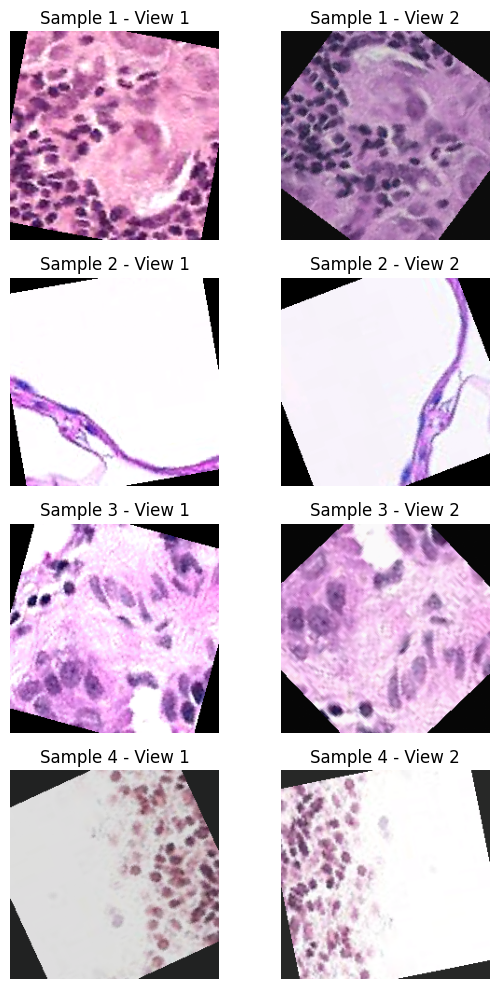

Augmentation preview saved to: /kaggle/working/pipeline2_contrastive_vit/results/contrastive_augmentation_examples.png


In [12]:
# ==============================================================================
# CELL 11: Sanity Visualization of Augmented Positive Views
# ==============================================================================
# Un-normalize helper function
def denormalize(tensor):
    t = tensor.clone()
    for c, m, s in zip(t, imagenet_mean, imagenet_std):
        c.mul_(s).add_(m)
    return torch.clamp(t, 0, 1).permute(1, 2, 0).numpy()

temp_dataset = PCamHDF5Dataset(X_H5_PATH, Y_H5_PATH, transform=contrastive_transform)
fig, axes = plt.subplots(4, 2, figsize=(6, 10))

for i in range(4):
    (v1, v2), _ = temp_dataset[train_indices[i]]
    axes[i, 0].imshow(denormalize(v1))
    axes[i, 0].set_title(f"Sample {i+1} - View 1")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(denormalize(v2))
    axes[i, 1].set_title(f"Sample {i+1} - View 2")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig(results_dir / "contrastive_augmentation_examples.png", dpi=300)
plt.show()
print(f"Augmentation preview saved to: {results_dir / 'contrastive_augmentation_examples.png'}")

In [13]:
# ==============================================================================
# CELL 12: Self-Supervised Contrastive Dataset Wrapper
# ==============================================================================
class ContrastivePCamDataset(Dataset):
    """
    Dataset wrapper returning dual-view tuples (v1, v2) without targets.
    """
    def __init__(self, base_dataset, indices):
        self.base_dataset = base_dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        (v1, v2), _ = self.base_dataset[real_idx]
        return v1, v2

print("Contrastive PCam Dataset defined.")

Contrastive PCam Dataset defined.


In [14]:
# ==============================================================================
# CELL 13: Contrastive DataLoader Construction
# ==============================================================================
raw_contrastive_dataset = PCamHDF5Dataset(X_H5_PATH, Y_H5_PATH, transform=contrastive_transform)
contrastive_subset = ContrastivePCamDataset(raw_contrastive_dataset, train_indices)

contrastive_loader = DataLoader(
    contrastive_subset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=torch.cuda.is_available(),
    drop_last=True
)

print(f"Contrastive DataLoader initialized: {len(contrastive_loader)} batches (Batch Size: {CONFIG['batch_size']})")

Contrastive DataLoader initialized: 1000 batches (Batch Size: 16)


In [15]:
# ==============================================================================
# CELL 14: ViT Backbone Creation
# ==============================================================================
def create_vit_encoder(model_name="vit_tiny_patch16_224"):
    """
    Instantiates ViT encoder stripped of its original classification head.
    Outputs feature embedding z of size [B, 192].
    """
    encoder = timm.create_model(
        model_name,
        pretrained=True,
        num_classes=0  # Removes original classifier head
    )
    return encoder

test_enc = create_vit_encoder()
print(f"ViT Backbone Created. Output feature dimension: {test_enc.num_features}")

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

ViT Backbone Created. Output feature dimension: 192


In [16]:
# ==============================================================================
# CELL 15: Projection MLP Head
# ==============================================================================
class ProjectionHead(nn.Module):
    """
    Non-linear Projection MLP Head mapping encoder features to contrastive space.
    """
    def __init__(self, in_dim=192, hidden_dim=512, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)

print("Projection MLP Head defined.")

Projection MLP Head defined.


In [17]:
# ==============================================================================
# CELL 16: Complete Contrastive ViT Assembly
# ==============================================================================
class ContrastiveViT(nn.Module):
    def __init__(self, model_name="vit_tiny_patch16_224", hidden_dim=512, projection_dim=128):
        super().__init__()
        self.encoder = create_vit_encoder(model_name)
        in_features = self.encoder.num_features
        self.projection_head = ProjectionHead(in_features, hidden_dim, projection_dim)

    def forward_encoder(self, x):
        return self.encoder(x)

    def forward(self, v1, v2):
        # Extract features
        h1 = self.encoder(v1)
        h2 = self.encoder(v2)
        
        # Project embeddings
        z1 = self.projection_head(h1)
        z2 = self.projection_head(h2)
        
        # L2-normalize projection embeddings
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)
        
        return z1, z2

contrastive_model = ContrastiveViT(
    CONFIG["model_name"], CONFIG["hidden_dim"], CONFIG["projection_dim"]
).to(device)

print("Contrastive ViT initialized on device:", device)

Contrastive ViT initialized on device: cuda


In [18]:
# ==============================================================================
# CELL 17: NT-Xent / InfoNCE Loss Implementation
# ==============================================================================
class NTXentLoss(nn.Module):
    """
    Normalized Temperature-scaled Cross Entropy Loss (NT-Xent / InfoNCE).
    Mathematical Definition:
      For normalized embeddings z_i, z_j, cosine similarity is s_{i,j} = z_i^T z_j.
      Loss for pair (i,j) is: -log( exp(s_{i,j} / tau) / sum_{k != i} exp(s_{i,k} / tau) )
    """
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature
        self.cross_entropy = nn.CrossEntropyLoss(reduction="mean")

    def forward(self, z1, z2):
        batch_size = z1.size(0)
        
        # Concatenate embeddings: shape [2*B, proj_dim]
        z = torch.cat([z1, z2], dim=0)
        
        # Similarity matrix: shape [2*B, 2*B]
        sim_matrix = torch.matmul(z, z.T) / self.temperature
        
        # Mask out self-similarity on the diagonal
        mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)
        sim_matrix.masked_fill_(mask, -9e15)
        
        # Positives mapping: (i, i+B) and (i+B, i)
        targets = torch.cat([
            torch.arange(batch_size, 2 * batch_size, device=z.device),
            torch.arange(0, batch_size, device=z.device)
        ], dim=0)
        
        loss = self.cross_entropy(sim_matrix, targets)
        return loss

contrastive_criterion = NTXentLoss(temperature=CONFIG["temperature"])
print(f"NT-Xent Loss defined (Temperature: {CONFIG['temperature']}).")

NT-Xent Loss defined (Temperature: 0.5).


In [19]:
# ==============================================================================
# CELL 18: Contrastive Pipeline Forward & Backward Sanity Check
# ==============================================================================
print("Running Contrastive Forward/Backward Sanity Check...")

v1_dummy, v2_dummy = next(iter(contrastive_loader))
v1_dummy, v2_dummy = v1_dummy.to(device), v2_dummy.to(device)

contrastive_model.eval()
with torch.no_grad():
    z1_test, z2_test = contrastive_model(v1_dummy, v2_dummy)
    test_loss = contrastive_criterion(z1_test, z2_test)

print(f" -> View 1 Shape  : {list(v1_dummy.shape)}")
print(f" -> View 2 Shape  : {list(v2_dummy.shape)}")
print(f" -> Output z1 Shape: {list(z1_test.shape)}")
print(f" -> Output z2 Shape: {list(z2_test.shape)}")
print(f" -> Initial Loss   : {test_loss.item():.4f}")

# Test gradient flow
contrastive_model.train()
opt_test = torch.optim.AdamW(contrastive_model.parameters(), lr=1e-4)
opt_test.zero_grad()
z1_tr, z2_tr = contrastive_model(v1_dummy, v2_dummy)
loss_tr = contrastive_criterion(z1_tr, z2_tr)
loss_tr.backward()
opt_test.step()

print(" -> Backward Pass  : Successful (Gradients Updated)")
contrastive_model.zero_grad()

Running Contrastive Forward/Backward Sanity Check...
 -> View 1 Shape  : [16, 3, 224, 224]
 -> View 2 Shape  : [16, 3, 224, 224]
 -> Output z1 Shape: [16, 128]
 -> Output z2 Shape: [16, 128]
 -> Initial Loss   : 3.2329
 -> Backward Pass  : Successful (Gradients Updated)


In [20]:
# ==============================================================================
# CELL 19: Contrastive Pretraining Loop Engine
# ==============================================================================
def train_contrastive_epoch(model, loader, criterion, optimizer, scaler, accum_steps, device):
    model.train()
    running_loss = 0.0
    total_samples = 0
    optimizer.zero_grad()

    for i, (v1, v2) in enumerate(loader):
        v1 = v1.to(device, non_blocking=True)
        v2 = v2.to(device, non_blocking=True)

        if CONFIG["mixed_precision"]:
            with autocast("cuda"):
                z1, z2 = model(v1, v2)
                loss = criterion(z1, z2) / accum_steps
            scaler.scale(loss).backward()

            if (i + 1) % accum_steps == 0 or (i + 1) == len(loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
        else:
            z1, z2 = model(v1, v2)
            loss = criterion(z1, z2) / accum_steps
            loss.backward()

            if (i + 1) % accum_steps == 0 or (i + 1) == len(loader):
                optimizer.step()
                optimizer.zero_grad()

        running_loss += loss.item() * accum_steps * v1.size(0)
        total_samples += v1.size(0)

    return running_loss / total_samples

print("Contrastive training engine built.")

Contrastive training engine built.


In [21]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import GradScaler, autocast

# ==============================================================================
# Robust NT-Xent Loss (AMP FP16/BF16/FP32 Compatible)
# ==============================================================================
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature
        self.cross_entropy = nn.CrossEntropyLoss(reduction="mean")

    def forward(self, z1, z2):
        batch_size = z1.size(0)
        z = torch.cat([z1, z2], dim=0)
        sim_matrix = torch.matmul(z, z.T) / self.temperature
        
        # Mask out self-similarity on the diagonal
        mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)
        
        # Get the minimum finite value safe for the current tensor dtype (FP16/FP32)
        min_val = torch.finfo(sim_matrix.dtype).min
        
        # Fill diagonal safely without triggering overflow errors
        sim_matrix = sim_matrix.masked_fill(mask, min_val)
        
        targets = torch.cat([
            torch.arange(batch_size, 2 * batch_size, device=z.device),
            torch.arange(0, batch_size, device=z.device)
        ], dim=0)
        
        return self.cross_entropy(sim_matrix, targets)

# Re-instantiate criterion with AMP-safe class definition
contrastive_criterion = NTXentLoss(temperature=CONFIG["temperature"]).to(device)

# ==============================================================================
# STAGE 1 PRETRAINING EXECUTION
# ==============================================================================
print("\n==================================================")
print("STAGE 1: CONTRASTIVE PRETRAINING (7,000 Train Images)")
print("==================================================")

if torch.cuda.is_available():
    torch.cuda.empty_cache()

contrastive_optimizer = torch.optim.AdamW(
    contrastive_model.parameters(), 
    lr=CONFIG["contrastive_lr"], 
    weight_decay=CONFIG["weight_decay"]
)

scaler = GradScaler('cuda', enabled=CONFIG["mixed_precision"])

contrastive_history = {"epoch": [], "contrastive_loss": [], "time_sec": []}

start_pretrain_time = time.time()

for epoch in range(1, CONFIG["contrastive_epochs"] + 1):
    e_start = time.time()
    
    c_loss = train_contrastive_epoch(
        contrastive_model, 
        contrastive_loader, 
        contrastive_criterion,
        contrastive_optimizer, 
        scaler, 
        CONFIG["grad_accum_steps"], 
        device
    )
    
    e_time = time.time() - e_start

    contrastive_history["epoch"].append(epoch)
    contrastive_history["contrastive_loss"].append(c_loss)
    contrastive_history["time_sec"].append(e_time)

    print(f"Pretrain Epoch [{epoch:02d}/{CONFIG['contrastive_epochs']:02d}] "
          f"| NT-Xent Loss: {c_loss:.4f} | Time: {e_time:.2f}s")

total_pretrain_time = time.time() - start_pretrain_time
print(f"\nStage 1 Complete in {total_pretrain_time / 60:.2f} minutes.")


STAGE 1: CONTRASTIVE PRETRAINING (7,000 Train Images)
Pretrain Epoch [01/50] | NT-Xent Loss: 1.9189 | Time: 191.75s
Pretrain Epoch [02/50] | NT-Xent Loss: 1.8204 | Time: 158.57s
Pretrain Epoch [03/50] | NT-Xent Loss: 1.7948 | Time: 158.74s
Pretrain Epoch [04/50] | NT-Xent Loss: 1.7892 | Time: 158.79s
Pretrain Epoch [05/50] | NT-Xent Loss: 1.7761 | Time: 161.23s
Pretrain Epoch [06/50] | NT-Xent Loss: 1.7701 | Time: 158.06s
Pretrain Epoch [07/50] | NT-Xent Loss: 1.7670 | Time: 161.25s
Pretrain Epoch [08/50] | NT-Xent Loss: 1.7592 | Time: 160.51s
Pretrain Epoch [09/50] | NT-Xent Loss: 1.7562 | Time: 159.50s
Pretrain Epoch [10/50] | NT-Xent Loss: 1.7498 | Time: 159.20s
Pretrain Epoch [11/50] | NT-Xent Loss: 1.7524 | Time: 158.88s
Pretrain Epoch [12/50] | NT-Xent Loss: 1.7418 | Time: 162.24s
Pretrain Epoch [13/50] | NT-Xent Loss: 1.7402 | Time: 160.60s
Pretrain Epoch [14/50] | NT-Xent Loss: 1.7387 | Time: 157.03s
Pretrain Epoch [15/50] | NT-Xent Loss: 1.7375 | Time: 158.34s
Pretrain Epoch 

In [22]:
# # ==============================================================================
# # CELL 20: Execution of Contrastive Pretraining Stage
# # ==============================================================================
# import time
# import torch
# from torch.amp import GradScaler

# print("\n==================================================")
# print("STAGE 1: CONTRASTIVE PRETRAINING (2,000 Train Images)")
# print("==================================================")

# # Clear CUDA cache before starting long pretraining run
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()

# # Initialize Optimizer and Scaler with PyTorch AMP syntax
# contrastive_optimizer = torch.optim.AdamW(
#     contrastive_model.parameters(), 
#     lr=CONFIG["contrastive_lr"], 
#     weight_decay=CONFIG["weight_decay"]
# )

# scaler = GradScaler('cuda', enabled=CONFIG["mixed_precision"])

# contrastive_history = {"epoch": [], "contrastive_loss": [], "time_sec": []}

# start_pretrain_time = time.time()

# for epoch in range(1, CONFIG["contrastive_epochs"] + 1):
#     e_start = time.time()
    
#     c_loss = train_contrastive_epoch(
#         contrastive_model, 
#         contrastive_loader, 
#         contrastive_criterion,
#         contrastive_optimizer, 
#         scaler, 
#         CONFIG["grad_accum_steps"], 
#         device
#     )
    
#     e_time = time.time() - e_start

#     contrastive_history["epoch"].append(epoch)
#     contrastive_history["contrastive_loss"].append(c_loss)
#     contrastive_history["time_sec"].append(e_time)

#     print(f"Pretrain Epoch [{epoch:02d}/{CONFIG['contrastive_epochs']:02d}] "
#           f"| NT-Xent Loss: {c_loss:.4f} | Time: {e_time:.2f}s")

# total_pretrain_time = time.time() - start_pretrain_time
# print(f"\nStage 1 Complete in {total_pretrain_time / 60:.2f} minutes.")

In [23]:
# ==============================================================================
# CELL 21: Save Contrastive Checkpoint
# ==============================================================================
contrastive_ckpt_path = checkpoints_dir / "contrastive_vit_pretrained.pth"

torch.save({
    "epoch": CONFIG["contrastive_epochs"],
    "encoder_state_dict": contrastive_model.encoder.state_dict(),
    "projection_head_state_dict": contrastive_model.projection_head.state_dict(),
    "optimizer_state_dict": contrastive_optimizer.state_dict(),
    "config": CONFIG,
    "final_contrastive_loss": contrastive_history["contrastive_loss"][-1]
}, contrastive_ckpt_path)

print(f"Saved Contrastive Model Checkpoint to: {contrastive_ckpt_path}")

Saved Contrastive Model Checkpoint to: /kaggle/working/pipeline2_contrastive_vit/checkpoints/contrastive_vit_pretrained.pth


In [24]:
# ==============================================================================
# CELL 22: Supervised Data Transforms & Datasets
# ==============================================================================
train_finetune_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

eval_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

print("Supervised transforms configured.")

Supervised transforms configured.


In [25]:
# ==============================================================================
# CELL 23: Supervised DataLoaders Creation
# ==============================================================================
ds_train = PCamHDF5Dataset(X_H5_PATH, Y_H5_PATH, transform=train_finetune_transform)
ds_val   = PCamHDF5Dataset(X_H5_PATH, Y_H5_PATH, transform=eval_transform)
ds_test  = PCamHDF5Dataset(X_H5_PATH, Y_H5_PATH, transform=eval_transform)

subset_train = Subset(ds_train, train_indices)
subset_val   = Subset(ds_val, val_indices)
subset_test  = Subset(ds_test, test_indices)

train_ft_loader = DataLoader(
    subset_train, batch_size=CONFIG["batch_size"], shuffle=True,
    num_workers=CONFIG["num_workers"], pin_memory=torch.cuda.is_available()
)

val_ft_loader = DataLoader(
    subset_val, batch_size=CONFIG["batch_size"], shuffle=False,
    num_workers=CONFIG["num_workers"], pin_memory=torch.cuda.is_available()
)

test_ft_loader = DataLoader(
    subset_test, batch_size=CONFIG["batch_size"], shuffle=False,
    num_workers=CONFIG["num_workers"], pin_memory=torch.cuda.is_available()
)

print(f"Supervised Loaders -> Train: {len(train_ft_loader)} batches | Val: {len(val_ft_loader)} batches | Test: {len(test_ft_loader)} batches")

Supervised Loaders -> Train: 1000 batches | Val: 125 batches | Test: 125 batches


In [26]:
# ==============================================================================
# CELL 24: Instantiate Classification Model Assembly
# ==============================================================================
class PCamViTClassifier(nn.Module):
    """
    Attaches a 2-class linear classifier directly onto the contrastive-pretrained ViT encoder.
    """
    def __init__(self, encoder, num_classes=2, freeze_encoder=False):
        super().__init__()
        self.encoder = encoder
        
        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False
                
        in_features = self.encoder.num_features
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        features = self.encoder(x)
        logits = self.classifier(features)
        return logits

print("PCamViTClassifier model class ready.")

PCamViTClassifier model class ready.


In [27]:
# ==============================================================================
# CELL 25: Load Pretrained Weights & Attach Classifier Head
# ==============================================================================
print("\nLoading contrastive encoder weights into classification model...")

# Re-instantiate a clean encoder backbone
ft_encoder = create_vit_encoder(CONFIG["model_name"])

# Load learned weights from Stage 1 checkpoint
ckpt = torch.load(contrastive_ckpt_path, map_location=device)
ft_encoder.load_state_dict(ckpt["encoder_state_dict"])

# Construct classification model
finetune_model = PCamViTClassifier(
    ft_encoder, num_classes=CONFIG["num_classes"], freeze_encoder=CONFIG["freeze_encoder"]
).to(device)

print(f"Encoder initialized with contrastive weights. Strategy: {'Frozen Encoder' if CONFIG['freeze_encoder'] else 'Full Fine-Tuning'}")


Loading contrastive encoder weights into classification model...
Encoder initialized with contrastive weights. Strategy: Full Fine-Tuning


In [28]:
# ==============================================================================
# CELL 26: Supervised Training Step Function
# ==============================================================================
def train_supervised_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        if CONFIG["mixed_precision"]:
            with autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels).item()
        total += labels.size(0)

    return running_loss / total, correct / total

print("Supervised train step engine defined.")

Supervised train step engine defined.


In [29]:
# ==============================================================================
# CELL 27: Supervised Validation Step Function
# ==============================================================================
def validate_supervised_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if CONFIG["mixed_precision"]:
                with autocast("cuda"):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)

    return running_loss / total, correct / total

print("Supervised validation step engine defined.")

Supervised validation step engine defined.


In [30]:
# ==============================================================================
# CELL 28: Execution of Supervised Fine-Tuning Stage
# ==============================================================================
print("\n==================================================")
print("STAGE 2: SUPERVISED FINE-TUNING")
print("==================================================")

ft_optimizer = torch.optim.AdamW(
    finetune_model.parameters(), lr=CONFIG["finetune_lr"], weight_decay=CONFIG["weight_decay"]
)
ft_criterion = nn.CrossEntropyLoss()
ft_scaler = GradScaler('cuda', enabled=CONFIG["mixed_precision"])

finetune_history = {
    "epoch": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "time_sec": []
}

best_val_acc = 0.0
best_ft_ckpt_path = checkpoints_dir / "best_contrastive_finetuned_vit.pth"

start_ft_time = time.time()

for epoch in range(1, CONFIG["finetune_epochs"] + 1):
    e_start = time.time()

    t_loss, t_acc = train_supervised_epoch(
        finetune_model, train_ft_loader, ft_criterion, ft_optimizer, ft_scaler, device
    )
    v_loss, v_acc = validate_supervised_epoch(
        finetune_model, val_ft_loader, ft_criterion, device
    )
    e_time = time.time() - e_start

    finetune_history["epoch"].append(epoch)
    finetune_history["train_loss"].append(t_loss)
    finetune_history["train_acc"].append(t_acc)
    finetune_history["val_loss"].append(v_loss)
    finetune_history["val_acc"].append(v_acc)
    finetune_history["time_sec"].append(e_time)

    print(f"Epoch [{epoch:02d}/{CONFIG['finetune_epochs']:02d}] "
          f"Train Loss: {t_loss:.4f} | Train Acc: {t_acc*100:.2f}% | "
          f"Val Loss: {v_loss:.4f} | Val Acc: {v_acc*100:.2f}% | Time: {e_time:.2f}s")

    # Save Checkpoint based on Validation Accuracy
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save({
            "epoch": epoch,
            "model_state_dict": finetune_model.state_dict(),
            "optimizer_state_dict": ft_optimizer.state_dict(),
            "best_val_accuracy": best_val_acc,
            "config": CONFIG
        }, best_ft_ckpt_path)
        print(f" --> Best Checkpoint Saved! (Val Acc: {best_val_acc*100:.2f}%)")

print(f"\nStage 2 Fine-Tuning Complete in {(time.time() - start_ft_time)/60:.2f} minutes.")


STAGE 2: SUPERVISED FINE-TUNING
Epoch [01/50] Train Loss: 0.2594 | Train Acc: 89.26% | Val Loss: 0.1641 | Val Acc: 93.70% | Time: 51.01s
 --> Best Checkpoint Saved! (Val Acc: 93.70%)
Epoch [02/50] Train Loss: 0.1901 | Train Acc: 92.82% | Val Loss: 0.1557 | Val Acc: 93.85% | Time: 48.94s
 --> Best Checkpoint Saved! (Val Acc: 93.85%)
Epoch [03/50] Train Loss: 0.1687 | Train Acc: 93.58% | Val Loss: 0.1486 | Val Acc: 94.10% | Time: 51.14s
 --> Best Checkpoint Saved! (Val Acc: 94.10%)
Epoch [04/50] Train Loss: 0.1500 | Train Acc: 94.28% | Val Loss: 0.1507 | Val Acc: 94.35% | Time: 48.21s
 --> Best Checkpoint Saved! (Val Acc: 94.35%)
Epoch [05/50] Train Loss: 0.1413 | Train Acc: 94.61% | Val Loss: 0.1384 | Val Acc: 95.05% | Time: 47.69s
 --> Best Checkpoint Saved! (Val Acc: 95.05%)
Epoch [06/50] Train Loss: 0.1269 | Train Acc: 95.21% | Val Loss: 0.1324 | Val Acc: 95.75% | Time: 51.55s
 --> Best Checkpoint Saved! (Val Acc: 95.75%)
Epoch [07/50] Train Loss: 0.1173 | Train Acc: 95.69% | Val Lo

In [31]:
# ==============================================================================
# CELL 29: Load Best Supervised Checkpoint
# ==============================================================================
print("\nLoading Best Fine-Tuned Checkpoint for Final Evaluation...")
assert best_ft_ckpt_path.exists(), "Best checkpoint file does not exist!"

best_ckpt = torch.load(best_ft_ckpt_path, map_location=device)
finetune_model.load_state_dict(best_ckpt["model_state_dict"])
print(f"Successfully loaded model checkpoint from Epoch {best_ckpt['epoch']} (Validation Acc: {best_ckpt['best_val_accuracy']*100:.2f}%)")


Loading Best Fine-Tuned Checkpoint for Final Evaluation...
Successfully loaded model checkpoint from Epoch 18 (Validation Acc: 96.55%)


In [32]:
# ==============================================================================
# CELL 30: Evaluation on Held-Out Test Set (500 Samples)
# ==============================================================================
print("\nEvaluating Model on Held-Out Test Set...")
finetune_model.eval()

test_indices_list = []
true_labels = []
pred_labels = []
prob_class_0 = []
prob_class_1 = []

rel_idx = 0
with torch.no_grad():
    for images, labels in test_ft_loader:
        images = images.to(device)

        if CONFIG["mixed_precision"]:
            with autocast("cuda"):
                logits = finetune_model(images)
        else:
            logits = finetune_model(images)

        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        labels_np = labels.numpy()

        for i in range(len(labels_np)):
            test_indices_list.append(int(test_indices[rel_idx]))
            true_labels.append(int(labels_np[i]))
            pred_labels.append(int(preds[i]))
            prob_class_0.append(float(probs[i, 0]))
            prob_class_1.append(float(probs[i, 1]))
            rel_idx += 1

print("Test Set inference complete.")


Evaluating Model on Held-Out Test Set...
Test Set inference complete.


In [33]:
# ==============================================================================
# CELL 31: Test Performance Metrics Calculation
# ==============================================================================
acc = accuracy_score(true_labels, pred_labels)
prec = precision_score(true_labels, pred_labels, average="binary")
rec = recall_score(true_labels, pred_labels, average="binary")
f1 = f1_score(true_labels, pred_labels, average="binary")
auc = roc_auc_score(true_labels, prob_class_1)

print("\n------------------------------")
print("PIPELINE-2 TEST RESULTS")
print("------------------------------")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")


------------------------------
PIPELINE-2 TEST RESULTS
------------------------------
Accuracy  : 0.9595
Precision : 0.9637
Recall    : 0.9550
F1-Score  : 0.9593
ROC-AUC   : 0.9885


In [34]:
# ==============================================================================
# CELL 32: Confusion Matrix Generation
# ==============================================================================
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Non-Tumor (0)", "Tumor (1)"],
            yticklabels=["Non-Tumor (0)", "Tumor (1)"])
plt.title("Pipeline-2 Contrastive ViT - PCam Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.savefig(results_dir / "confusion_matrix.png", dpi=300)
plt.close()

print(f"Saved: {results_dir / 'confusion_matrix.png'}")

Saved: /kaggle/working/pipeline2_contrastive_vit/results/confusion_matrix.png


In [35]:
# ==============================================================================
# CELL 33: ROC Curve Plot Generation
# ==============================================================================
fpr, tpr, _ = roc_curve(true_labels, prob_class_1)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"Pipeline-2 (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Pipeline-2 Contrastive ViT - ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "roc_curve.png", dpi=300)
plt.close()

print(f"Saved: {results_dir / 'roc_curve.png'}")

Saved: /kaggle/working/pipeline2_contrastive_vit/results/roc_curve.png


In [36]:
# ==============================================================================
# CELL 34: Stage 1 and Stage 2 Training History Curves
# ==============================================================================
# 1. Stage 1 Contrastive Loss Curve
plt.figure(figsize=(6, 4))
plt.plot(contrastive_history["epoch"], contrastive_history["contrastive_loss"], marker='o', color='purple')
plt.title("Stage 1 - NT-Xent Contrastive Loss Curve")
plt.xlabel("Pretrain Epoch")
plt.ylabel("NT-Xent Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "contrastive_loss_curve.png", dpi=300)
plt.close()

# 2. Stage 2 Fine-Tuning Loss Curve
plt.figure(figsize=(6, 4))
plt.plot(finetune_history["epoch"], finetune_history["train_loss"], label="Train Loss", marker='o')
plt.plot(finetune_history["epoch"], finetune_history["val_loss"], label="Val Loss", marker='s')
plt.title("Stage 2 - Supervised Fine-Tuning Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "finetune_loss_curve.png", dpi=300)
plt.close()

# 3. Stage 2 Fine-Tuning Accuracy Curve
plt.figure(figsize=(6, 4))
plt.plot(finetune_history["epoch"], [a*100 for a in finetune_history["train_acc"]], label="Train Acc", marker='o')
plt.plot(finetune_history["epoch"], [a*100 for a in finetune_history["val_acc"]], label="Val Acc", marker='s')
plt.title("Stage 2 - Supervised Fine-Tuning Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "finetune_accuracy_curve.png", dpi=300)
plt.close()

print("All learning curve plots generated and saved.")

All learning curve plots generated and saved.


In [37]:
# ==============================================================================
# CELL 35: Save Test Set Predictions DataFrame CSV
# ==============================================================================
df_preds = pd.DataFrame({
    "index": test_indices_list,
    "true_label": true_labels,
    "predicted_label": pred_labels,
    "probability_class_0": prob_class_0,
    "probability_class_1": prob_class_1
})

df_preds.to_csv(results_dir / "predictions.csv", index=False)
print(f"Saved: {results_dir / 'predictions.csv'}")

Saved: /kaggle/working/pipeline2_contrastive_vit/results/predictions.csv


In [38]:
# ==============================================================================
# CELL 36: Export Stage Histories and Final Metrics JSON
# ==============================================================================
# Export Stage Histories
pd.DataFrame(contrastive_history).to_csv(results_dir / "contrastive_history.csv", index=False)
pd.DataFrame(finetune_history).to_csv(results_dir / "finetune_history.csv", index=False)

# Export Metrics JSON Payload
metrics_payload = {
    "pipeline": "Pipeline-2",
    "model": "Contrastive ViT",
    "dataset": "PCam",
    "total_images": CONFIG["total_samples"],
    "train_images": CONFIG["train_samples"],
    "validation_images": CONFIG["val_samples"],
    "test_images": CONFIG["test_samples"],
    "seed": CONFIG["seed"],
    "image_size": CONFIG["image_size"],
    "model_name": CONFIG["model_name"],
    "contrastive": {
        "epochs": CONFIG["contrastive_epochs"],
        "temperature": CONFIG["temperature"],
        "projection_dim": CONFIG["projection_dim"],
        "final_loss": float(contrastive_history["contrastive_loss"][-1])
    },
    "fine_tuning": {
        "epochs": CONFIG["finetune_epochs"],
        "freeze_encoder": CONFIG["freeze_encoder"]
    },
    "test_metrics": {
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "roc_auc": float(auc)
    }
}

with open(results_dir / "metrics.json", "w") as f:
    json.dump(metrics_payload, f, indent=4)

print(f"Saved: {results_dir / 'metrics.json'}")

Saved: /kaggle/working/pipeline2_contrastive_vit/results/metrics.json


In [39]:
# ==============================================================================
# CELL 37: Configuration Metadata Backup
# ==============================================================================
with open(config_dir / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=4)

print("Configuration metadata saved.")

Configuration metadata saved.


In [40]:
# ==============================================================================
# CELL 38: Execution Summary
# ==============================================================================
print("\n============================================================")
print("PIPELINE-2 CONTRASTIVE ViT — FINAL RESULT")
print("============================================================")
print(f"Dataset             : PCam")
print(f"Images used         : {CONFIG['total_samples']}")
print(f"  - Train           : {CONFIG['train_samples']}")
print(f"  - Validation      : {CONFIG['val_samples']}")
print(f"  - Test            : {CONFIG['test_samples']}")
print(f"Model               : {CONFIG['model_name']}")
print(f"Initial weights     : ImageNet pretrained")
print(f"Contrastive learning: NT-Xent / InfoNCE")
print(f"Temperature         : {CONFIG['temperature']}")
print(f"Projection dim      : {CONFIG['projection_dim']}")
print("------------------------------------------------------------")
print("CONTRASTIVE PRETRAINING")
print("------------------------------------------------------------")
print(f"Epochs              : {CONFIG['contrastive_epochs']}")
print(f"Final NT-Xent Loss  : {contrastive_history['contrastive_loss'][-1]:.4f}")
print("------------------------------------------------------------")
print("SUPERVISED FINE-TUNING")
print("------------------------------------------------------------")
print(f"Epochs              : {CONFIG['finetune_epochs']}")
print(f"Best Val Accuracy   : {best_val_acc*100:.2f}%")
print("------------------------------------------------------------")
print("TEST RESULTS")
print("------------------------------------------------------------")
print(f"Accuracy            : {acc:.4f}")
print(f"Precision           : {prec:.4f}")
print(f"Recall              : {rec:.4f}")
print(f"F1 Score            : {f1:.4f}")
print(f"ROC-AUC             : {auc:.4f}")
print("------------------------------------------------------------")
print("OUTPUT FILES SAVED IN /kaggle/working/pipeline2_contrastive_vit/")
print("------------------------------------------------------------")
print(f"Contrastive Checkpoint : {contrastive_ckpt_path}")
print(f"Fine-Tuned Checkpoint  : {best_ft_ckpt_path}")
print(f"Metrics JSON           : {results_dir / 'metrics.json'}")
print(f"Predictions CSV        : {results_dir / 'predictions.csv'}")
print(f"Confusion Matrix       : {results_dir / 'confusion_matrix.png'}")
print(f"ROC Curve              : {results_dir / 'roc_curve.png'}")
print("============================================================")


PIPELINE-2 CONTRASTIVE ViT — FINAL RESULT
Dataset             : PCam
Images used         : 20000
  - Train           : 16000
  - Validation      : 2000
  - Test            : 2000
Model               : vit_tiny_patch16_224
Initial weights     : ImageNet pretrained
Contrastive learning: NT-Xent / InfoNCE
Temperature         : 0.5
Projection dim      : 128
------------------------------------------------------------
CONTRASTIVE PRETRAINING
------------------------------------------------------------
Epochs              : 50
Final NT-Xent Loss  : 1.6999
------------------------------------------------------------
SUPERVISED FINE-TUNING
------------------------------------------------------------
Epochs              : 50
Best Val Accuracy   : 96.55%
------------------------------------------------------------
TEST RESULTS
------------------------------------------------------------
Accuracy            : 0.9595
Precision           : 0.9637
Recall              : 0.9550
F1 Score            : 